# Importing Library

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom , RandomTranslation , RandomContrast , RandomBrightness
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2

2025-09-27 23:57:30.094617: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Importing Dataset

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 6799 files belonging to 3 classes.
Using 5440 files for training.


I0000 00:00:1758995858.443195   52521 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5362 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 6799 files belonging to 3 classes.
Using 1359 files for validation.
Found 2278 files belonging to 3 classes.


# Data Preprocessing

In [7]:
data_augmentation = tf.keras.Sequential([
    RandomRotation(factor=(-0.025, 0.025)),
    RandomTranslation(height_factor=0.05, width_factor=0.05),
    RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05)),
    RandomContrast(factor=0.1),
    RandomFlip(mode="horizontal"),
    RandomBrightness(factor=0.1)
], name="data_augmentation")

def cutmix_sparse(batch_x, batch_y, alpha=1.0):
    batch_size = tf.shape(batch_x)[0]

    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_x = tf.gather(batch_x, indices)
    shuffled_y = tf.gather(batch_y, indices)

    lam = tf.random.uniform([], 0, 1)

    H, W = IMG_SIZE
    r_x = tf.cast(W * tf.random.uniform([], 0, 1), tf.int32)
    r_y = tf.cast(H * tf.random.uniform([], 0, 1), tf.int32)
    r_w = tf.cast(W * tf.math.sqrt(1 - lam), tf.int32)
    r_h = tf.cast(H * tf.math.sqrt(1 - lam), tf.int32)

    x1 = tf.clip_by_value(r_x - r_w // 2, 0, W)
    y1 = tf.clip_by_value(r_y - r_h // 2, 0, H)
    x2 = tf.clip_by_value(r_x + r_w // 2, 0, W)
    y2 = tf.clip_by_value(r_y + r_h // 2, 0, H)

    mask = tf.ones([y2 - y1, x2 - x1, 3])
    pad_top = y1
    pad_left = x1
    pad_bottom = H - y2
    pad_right = W - x2
    mask = tf.pad(mask, [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    mask = 1 - mask

    mixed_x = batch_x * mask + shuffled_x * (1 - mask)

    mixed_y = tf.where(lam > 0.5, batch_y, shuffled_y)

    return mixed_x, mixed_y


train_ds_augmented = train_ds.map(
    lambda x, y: cutmix_sparse(x, y), num_parallel_calls=AUTOTUNE
)


# Model Creation

In [8]:
def build_model(input_shape=IMG_SIZE+(3,), num_classes=3):
    base_model = ResNet50(
        include_top=False,
        input_shape=input_shape,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)      
    x = base_model(x, training=False)    
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation="softmax", kernel_regularizer=l2(1e-4))(x)
    model = Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=1000,
        t_mul=2.0,
        m_mul=0.8,
        alpha=1e-6
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=[SparseCategoricalAccuracy(name="accuracy")]
    )
    return model, base_model

model, base_model = build_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Training The Model

In [9]:
history1 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
)

Epoch 1/5


2025-09-28 00:00:16.453409: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


340/340 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.5143 - loss: 1.0492 - val_accuracy: 0.6210 - val_loss: 0.8146
Epoch 2/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.5737 - loss: 0.9361 - val_accuracy: 0.6542 - val_loss: 0.7653
Epoch 3/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.5853 - loss: 0.8995 - val_accuracy: 0.6703 - val_loss: 0.7304
Epoch 4/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.5803 - loss: 0.9339 - val_accuracy: 0.6689 - val_loss: 0.8009
Epoch 5/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.5996 - loss: 0.8937 - val_accuracy: 0.6990 - val_loss: 0.7038


# Fine Tuning

## Total Layers of The Base Model

In [10]:
print("Base model has", len(base_model.layers), "layers.")

Base model has 175 layers.


## Tuning Process

In [11]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), 
    loss="sparse_categorical_crossentropy",
    metrics=[SparseCategoricalAccuracy(name="accuracy")]
)

history2 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
    ]
)

Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 57s 129ms/step - accuracy: 0.6006 - loss: 0.8960 - val_accuracy: 0.6262 - val_loss: 1.1871 - learning_rate: 1.0000e-04
Epoch 2/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 51s 150ms/step - accuracy: 0.6445 - loss: 0.8157 - val_accuracy: 0.8109 - val_loss: 0.4603 - learning_rate: 1.0000e-04
Epoch 3/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.6892 - loss: 0.7364 - val_accuracy: 0.8271 - val_loss: 0.4395 - learning_rate: 1.0000e-04
Epoch 4/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 45s 131ms/step - accuracy: 0.7224 - loss: 0.6697 - val_accuracy: 0.8411 - val_loss: 0.4320 - learning_rate: 1.0000e-04
Epoch 5/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.7125 - loss: 0.7053 - val_accuracy: 0.8168 - val_loss: 0.4731 - learning_rate: 1.0000e-04
Epoch 6/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 125ms/step - accuracy: 0.7406 - loss: 0.6388 - val_accuracy: 0.8330 - val_loss: 0.4306 - learning_rate: 1.0000e-04
Epoch 7/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 12

# Evaluate

In [12]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8617 - loss: 0.3822
Test Accuracy: 0.8617208003997803


2025-09-28 00:09:51.022765: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


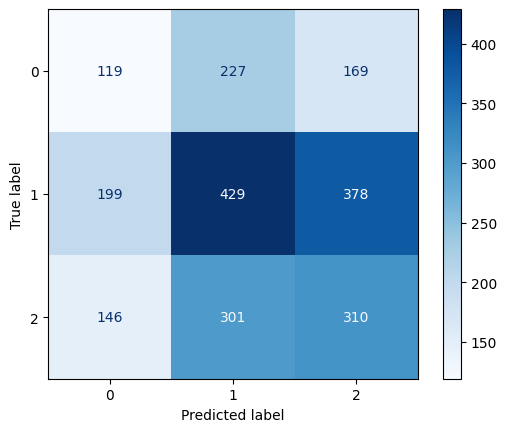

In [13]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
preds = model.predict(test_ds, verbose=0)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step


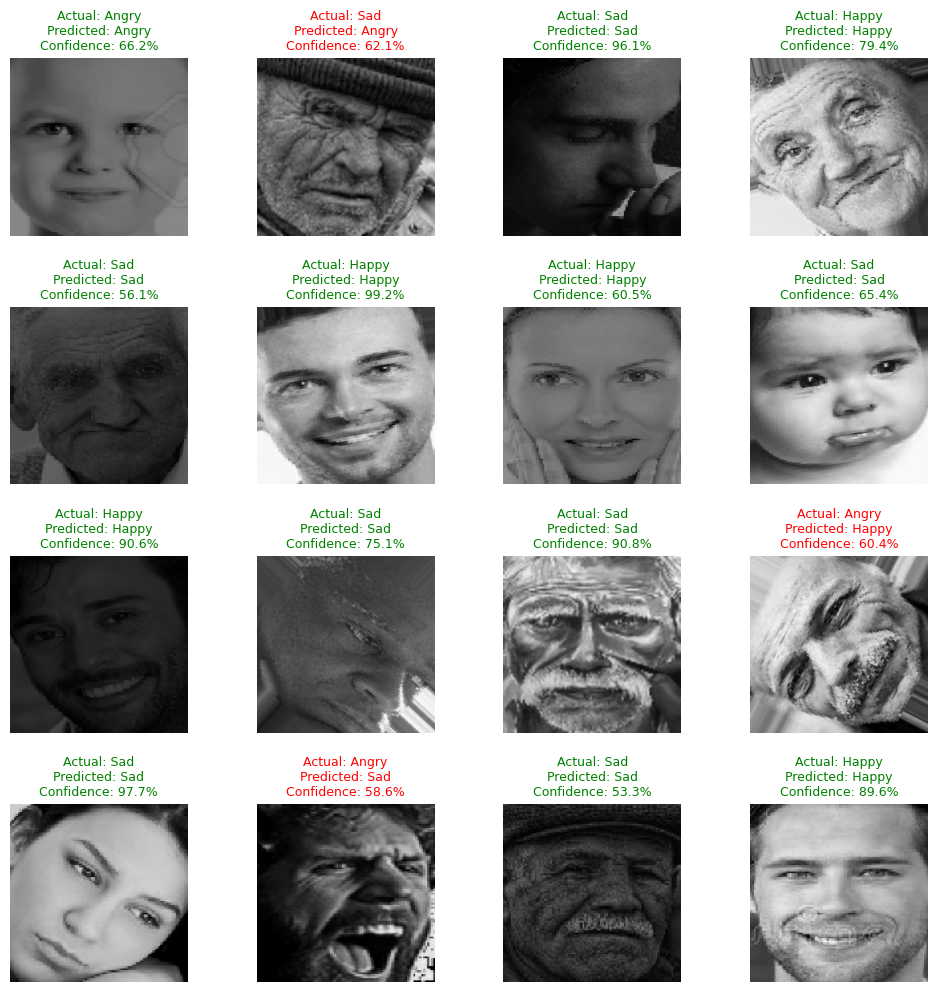

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted_full_multiclass(model, dataset, class_names, num_samples=16):
    rows = cols = int(np.sqrt(num_samples))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()
    for images, labels in dataset.take(1):  
        preds = model.predict(images)
        pred_labels = np.argmax(preds, axis=1)
        labels = labels.numpy()
        for i in range(min(num_samples, len(images))):
            img = images[i].numpy().astype("uint8")
            axes[i].imshow(img)
            
            true_label = class_names[labels[i]]
            predicted_label = class_names[pred_labels[i]]
            confidence = preds[i][pred_labels[i]]
            color = 'green' if labels[i] == pred_labels[i] else 'red'
            axes[i].set_title(f"Actual: {true_label}\nPredicted: {predicted_label}\nConfidence: {confidence*100:.1f}%",
                              fontsize=9, color=color)
            axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.show()
class_names = ['Angry', 'Happy', 'Sad']
plot_actual_vs_predicted_full_multiclass(model, test_ds, class_names, num_samples=16)
